# Election Data Deduplication Workflow

This notebook demonstrates the workflow for processing and deduplicating election data.

## Setup and Configuration

In [15]:
import sys
import os
from pathlib import Path
import pandas as pd

# Set the base directory and add to path
BASE_DIR = Path('/home/clu/Documents/GOODPARTY/election_deduplication')
INPUT_DIR = BASE_DIR / 'input'
sys.path.insert(0, str(BASE_DIR))

# Import necessary modules
from src.config import Config
from src.processor import ElectionProcessor
from src.database import ElectionDatabase
from src.analysis import ElectionAnalyzer

print("Modules imported successfully")

Modules imported successfully


## Step 1: Process Datasets

Process the CSV files through the extraction pipeline using Python invocations (equivalent to CLI commands).

In [16]:
# Configure the processing settings
# You can modify these settings as needed
PROVIDER = 'vllm'  # or 'litellm' for cloud APIs
BATCH_SIZE = 32
LIMIT = 99999  # Process first 2000 records from each file
STREAMING = False

# Load configuration
config = Config.from_env()
config.llm.provider = PROVIDER
config.processing.batch_size = BATCH_SIZE
config.processing.limit = LIMIT
config.processing.streaming = STREAMING

print(f"Configuration:")
print(f"  Provider: {config.llm.provider}")
print(f"  Batch size: {config.processing.batch_size}")
print(f"  Limit: {config.processing.limit}")
print(f"  Database: {config.database.db_path}")

Configuration:
  Provider: vllm
  Batch size: 32
  Limit: 99999
  Database: elections.db


### Process 'ours.csv'

In [17]:
# Create processor for ours.csv
llm_provider = config.create_llm_provider()
database = ElectionDatabase(config.database.db_path)
processor_ours = ElectionProcessor(llm_provider, database)

print("Processing 'ours.csv'...")
print("="*60)

# Process the CSV file
try:
    batch_ours = processor_ours.process_csv(
        str(INPUT_DIR / 'ours.csv'),
        batch_size=config.processing.batch_size,
        limit=config.processing.limit,
        streaming=config.processing.streaming
    )
    
    print(f"\nProcessing complete for 'ours.csv'")
    print(f"  Batch ID: {batch_ours.batch_id}")
    print(f"  Total processed: {batch_ours.processed_records}")
    print(f"  Successful: {batch_ours.processed_records - batch_ours.errors}")
    print(f"  Errors: {batch_ours.errors}")
    print(f"  Success rate: {batch_ours.success_rate:.1%}")
    
    # Show quick analysis
    processor_ours.analyze_results()
    
finally:
    processor_ours.close()

Reusing existing vLLM engine for Qwen/Qwen2.5-7B-Instruct
vLLM engine reused; guided_json ready.
Processing 'ours.csv'...
Processing /home/clu/Documents/GOODPARTY/election_deduplication/input/ours.csv
LLM Provider: VLLMProvider
Batch size: 32
Limit: 99999 records
Source file hash: 3471f6a613727aa8...
Loaded 2000 valid races from CSV (skipped 0)

Processing batch 1/63 (32 races)


Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Processing batch 2/63 (32 races)


Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Processing batch 63/63 (16 races)


Adding requests:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Processing complete!
Total processed: 2000
Errors: 0 (0.0%)
Success rate: 100.0%

Processing complete for 'ours.csv'
  Batch ID: 9dcea2cb-6383-487e-a133-645adaf393e6
  Total processed: 2000
  Successful: 2000
  Errors: 0
  Success rate: 100.0%

EXTRACTION ANALYSIS

Total records: 2000
Extraction errors: 0 (0.0%)
Unique entities: 1817

Entity Types:
  township: 516
  town: 403
  city: 400
  school_district: 295
  village: 284
  special_district: 81
  county: 21

Top Position Types:
  council: 509
  board_member: 461
  clerk: 248
  supervisor: 127
  commissioner: 126
  trustee: 121
  mayor: 99
  president: 97
  chairperson: 75
  treasurer: 72

Feature Detection:
  Has county: 856 (42.8%)
  Has district/ward: 605 (30.2%)
  At-large: 214 (10.7%)
  Special elections: 0 (0.0%)
  Multi-winner: 0 (0.0%)


### Process 'theirs.csv'

In [18]:
# Create processor for theirs.csv
llm_provider = config.create_llm_provider()
database = ElectionDatabase(config.database.db_path)
processor_theirs = ElectionProcessor(llm_provider, database)

print("Processing 'theirs.csv'...")
print("="*60)

# Process the CSV file
try:
    batch_theirs = processor_theirs.process_csv(
        str(INPUT_DIR / 'theirs.csv'),
        batch_size=config.processing.batch_size,
        limit=config.processing.limit,
        streaming=config.processing.streaming
    )
    
    print(f"\nProcessing complete for 'theirs.csv'")
    print(f"  Batch ID: {batch_theirs.batch_id}")
    print(f"  Total processed: {batch_theirs.processed_records}")
    print(f"  Successful: {batch_theirs.processed_records - batch_theirs.errors}")
    print(f"  Errors: {batch_theirs.errors}")
    print(f"  Success rate: {batch_theirs.success_rate:.1%}")
    
    # Show quick analysis
    processor_theirs.analyze_results()
    
finally:
    processor_theirs.close()

Reusing existing vLLM engine for Qwen/Qwen2.5-7B-Instruct
vLLM engine reused; guided_json ready.
Processing 'theirs.csv'...
Processing /home/clu/Documents/GOODPARTY/election_deduplication/input/theirs.csv
LLM Provider: VLLMProvider
Batch size: 32
Limit: 99999 records
Source file hash: 7e1562ae5a5444a0...
Loaded 2000 valid races from CSV (skipped 0)

Processing batch 1/63 (32 races)


Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Processing batch 2/63 (32 races)


Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Processing batch 63/63 (16 races)


Adding requests:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Processing complete!
Total processed: 2000
Errors: 0 (0.0%)
Success rate: 100.0%

Processing complete for 'theirs.csv'
  Batch ID: 8cfefca6-8407-40eb-aef4-dd720ed15bc5
  Total processed: 2000
  Successful: 2000
  Errors: 0
  Success rate: 100.0%

EXTRACTION ANALYSIS

Total records: 4000
Extraction errors: 0 (0.0%)
Unique entities: 3308

Entity Types:
  town: 913
  township: 802
  city: 744
  village: 656
  school_district: 621
  special_district: 237
  county: 27

Top Position Types:
  council: 728
  trustee: 637
  board_member: 606
  clerk: 486
  supervisor: 377
  commissioner: 256
  president: 204
  chairperson: 191
  mayor: 173
  treasurer: 170

Feature Detection:
  Has county: 1578 (39.5%)
  Has district/ward: 1551 (38.8%)
  At-large: 944 (23.6%)
  Special elections: 103 (2.6%)
  Multi-winner: 2 (0.1%)


### View Processing Summary

In [19]:
# Show source file provenance
database = ElectionDatabase(config.database.db_path)
sources = database.get_batch_sources()

if sources:
    print("Source Files Processed:")
    print("="*80)
    print(f"{'File Name':<20} {'Records':<10} {'Errors':<10} {'Hash':<20}")
    print("-"*80)
    
    for source in sources:
        print(f"{source['source_file']:<20} "
              f"{source['total_records']:<10} "
              f"{source['total_errors'] or 0:<10} "
              f"{source['source_hash'][:16] + '...'}")
    
    print(f"\nTotal records: {sum(s['total_records'] for s in sources)}")
    print(f"Total errors: {sum(s['total_errors'] or 0 for s in sources)}")

database.close()

Source Files Processed:
File Name            Records    Errors     Hash                
--------------------------------------------------------------------------------
theirs.csv           2000       0          7e1562ae5a5444a0...
ours.csv             2000       0          3471f6a613727aa8...

Total records: 4000
Total errors: 0


## Step 2: Run Analysis

Now we'll use the analysis module to perform deduplication and similarity matching on the processed data.

In [20]:
# Initialize the analyzer
analyzer = ElectionAnalyzer(db_path=str(BASE_DIR / 'elections.db'))

print("ElectionAnalyzer initialized with database: elections.db")

ElectionAnalyzer initialized with database: elections.db


### Find Exact Duplicates

In [21]:
# Find exact duplicates
duplicates = analyzer.find_exact_duplicates()

print(f"Found {len(duplicates)} groups of exact duplicates\n")

# Display top 5 duplicate groups
if duplicates:
    print("Top 5 duplicate groups:")
    print("="*60)
    for i, dup in enumerate(duplicates[:5], 1):
        print(f"\n{i}. Entity: {dup.get('entity_name', 'N/A')}")
        print(f"   Type: {dup.get('entity_type', 'N/A')}")
        print(f"   Position: {dup.get('position_type', 'N/A')}")
        print(f"   State: {dup.get('state', 'N/A')}")
        print(f"   Duplicate Count: {dup['duplicate_count']}")
        print(f"   Record IDs: {dup['record_ids'][:3]}{'...' if len(dup['record_ids']) > 3 else ''}")

Found 67 groups of exact duplicates

Top 5 duplicate groups:

1. Entity: Almon
   Type: town
   Position: clerk
   State: WI
   Duplicate Count: 2
   Record IDs: [423, 2403]

2. Entity: Altona
   Type: village
   Position: president
   State: IL
   Duplicate Count: 2
   Record IDs: [1911, 3591]

3. Entity: Amity Township
   Type: township
   Position: commissioner
   State: IL
   Duplicate Count: 2
   Record IDs: [483, 2212]

4. Entity: Anchor Township
   Type: township
   Position: supervisor
   State: IL
   Duplicate Count: 2
   Record IDs: [332, 2046]

5. Entity: Apple River Township
   Type: township
   Position: supervisor
   State: IL
   Duplicate Count: 2
   Record IDs: [1333, 3276]


In [22]:
# Show exact duplicate IDs and their sources
from typing import List, Dict

# Reuse the existing database connection helper
# ElectionDatabase was imported earlier

db = ElectionDatabase(config.database.db_path)


def fetch_records_by_ids(ids: List[int]) -> List[Dict]:
    if not ids:
        return []
    placeholders = ",".join(["?" for _ in ids])
    query = f"""
        SELECT e.id, e.batch_id, pb.source_file, e.original_text
        FROM elections e
        LEFT JOIN processing_batches pb ON e.batch_id = pb.batch_id
        WHERE e.id IN ({placeholders})
        ORDER BY e.id
    """
    cur = db.conn.cursor()
    cur.execute(query, ids)
    return [dict(row) for row in cur.fetchall()]


if duplicates:
    print("Exact duplicate records with source_file by group:")
    print("="*60)
    for i, dup in enumerate(duplicates, 1):  # match the top-5 summary above
        ids = dup.get('record_ids', [])
        print(f"\nGroup {i}: {dup.get('entity_name', 'N/A')} | {dup.get('entity_type', 'N/A')} | {dup.get('position_type', 'N/A')} | {dup.get('state', 'N/A')}")
        print(f"IDs: {ids}")
        rows = fetch_records_by_ids(ids)
        og_match = []
        for r in rows:
            og_match.append(r.get("original_text"))
        print(og_match)
        print()
        for r in rows:
            print(f"  - ID {r['id']}: source_file='{r.get('source_file')}', batch_id='{r.get('batch_id')}'")
else:
    print("No duplicates found.")



Exact duplicate records with source_file by group:

Group 1: Almon | town | clerk | WI
IDs: [423, 2403]
['WI Shawano County: Almon Town Clerk', 'WI Almon Town Clerk (Shawano County)']

  - ID 423: source_file='ours.csv', batch_id='9dcea2cb-6383-487e-a133-645adaf393e6'
  - ID 2403: source_file='theirs.csv', batch_id='8cfefca6-8407-40eb-aef4-dd720ed15bc5'

Group 2: Altona | village | president | IL
IDs: [1911, 3591]
['IL Altona Village President', 'IL Altona Village President']

  - ID 1911: source_file='ours.csv', batch_id='9dcea2cb-6383-487e-a133-645adaf393e6'
  - ID 3591: source_file='theirs.csv', batch_id='8cfefca6-8407-40eb-aef4-dd720ed15bc5'

Group 3: Amity Township | township | commissioner | IL
IDs: [483, 2212]
['IL Livingston County: Amity Township Highway Commissioner', 'IL Amity Township Highway Commissioner (Livingston County)']

  - ID 483: source_file='ours.csv', batch_id='9dcea2cb-6383-487e-a133-645adaf393e6'
  - ID 2212: source_file='theirs.csv', batch_id='8cfefca6-8407-4

## Level 7 Duplicate Match (almost exact)

In [39]:
# Find Level 7 duplicates
duplicates_l7 = analyzer.find_duplicates_at_level(level=7)

print(f"Found {len(duplicates_l7)} groups of LEVEL 7 duplicates\n")

# Display top 5 duplicate groups
if duplicates_l7:
    print("Top 5 duplicate groups:")
    print("="*60)
    for i, dup in enumerate(duplicates_l7[:5], 1):
        print(f"\n{i}. Entity: {dup.get('entity_name', 'N/A')}")
        print(f"   Type: {dup.get('entity_type', 'N/A')}")
        print(f"   Position: {dup.get('position_type', 'N/A')}")
        print(f"   State: {dup.get('state', 'N/A')}")
        print(f"   Duplicate Count: {dup['duplicate_count']}")
        print(f"   Record IDs: {dup['record_ids'][:3]}{'...' if len(dup['record_ids']) > 3 else ''}")

Found 71 groups of LEVEL 7 duplicates

Top 5 duplicate groups:

1. Entity: Algonquin Area Public Library District
   Type: special_district
   Position: trustee
   State: IL
   Duplicate Count: 2
   Record IDs: [2733, 3872]

2. Entity: Alma Village
   Type: village
   Position: trustee
   State: IL
   Duplicate Count: 2
   Record IDs: [2350, 3405]

3. Entity: Almon
   Type: town
   Position: clerk
   State: WI
   Duplicate Count: 2
   Record IDs: [423, 2403]

4. Entity: Altona
   Type: village
   Position: president
   State: IL
   Duplicate Count: 2
   Record IDs: [1911, 3591]

5. Entity: Amity Township
   Type: township
   Position: commissioner
   State: IL
   Duplicate Count: 2
   Record IDs: [483, 2212]


In [40]:
# Show exact duplicate IDs and their sources
from typing import List, Dict

# Reuse the existing database connection helper
# ElectionDatabase was imported earlier

db = ElectionDatabase(config.database.db_path)
def fetch_records_by_ids(ids: List[int]) -> List[Dict]:
    if not ids:
        return []
    placeholders = ",".join(["?" for _ in ids])
    query = f"""
        SELECT e.id, e.batch_id, pb.source_file, e.original_text
        FROM elections e
        LEFT JOIN processing_batches pb ON e.batch_id = pb.batch_id
        WHERE e.id IN ({placeholders})
        ORDER BY e.id
    """
    cur = db.conn.cursor()
    cur.execute(query, ids)
    return [dict(row) for row in cur.fetchall()]


if duplicates_l7:
    print("Exact duplicate records with source_file by group:")
    print("="*60)
    for i, dup in enumerate(duplicates_l7, 1):  # match the top-5 summary above
        ids = dup.get('record_ids', [])
        print(f"\nGroup {i}: {dup.get('entity_name', 'N/A')} | {dup.get('entity_type', 'N/A')} | {dup.get('position_type', 'N/A')} | {dup.get('state', 'N/A')}")
        print(f"IDs: {ids}")
        rows = fetch_records_by_ids(ids)
        og_match = []
        for r in rows:
            og_match.append(r.get("original_text"))
        print(og_match)
        print()
        for r in rows:
            print(f"  - ID {r['id']}: source_file='{r.get('source_file')}', batch_id='{r.get('batch_id')}'")
else:
    print("No duplicates found.")



Exact duplicate records with source_file by group:

Group 1: Algonquin Area Public Library District | special_district | trustee | IL
IDs: [2733, 3872]
['IL Algonquin Area Public Library District Trustee Board At-large', 'IL Algonquin Area Public Library District Trustee Board At-large Special']

  - ID 2733: source_file='theirs.csv', batch_id='8cfefca6-8407-40eb-aef4-dd720ed15bc5'
  - ID 3872: source_file='theirs.csv', batch_id='8cfefca6-8407-40eb-aef4-dd720ed15bc5'

Group 2: Alma Village | village | trustee | IL
IDs: [2350, 3405]
['IL Alma Village Trustee Board At-large Special', 'IL Alma Village Trustee Board At-large']

  - ID 2350: source_file='theirs.csv', batch_id='8cfefca6-8407-40eb-aef4-dd720ed15bc5'
  - ID 3405: source_file='theirs.csv', batch_id='8cfefca6-8407-40eb-aef4-dd720ed15bc5'

Group 3: Almon | town | clerk | WI
IDs: [423, 2403]
['WI Shawano County: Almon Town Clerk', 'WI Almon Town Clerk (Shawano County)']

  - ID 423: source_file='ours.csv', batch_id='9dcea2cb-6383-

In [41]:
# Get deduplication statistics
dedup_stats = analyzer.deduplicate_positions()

print("Deduplication Statistics")
print("="*40)
print(f"Total Records: {dedup_stats['total_records']:,}")
print(f"Unique Positions: {dedup_stats['unique_positions']:,}")
print(f"Duplicate Records: {dedup_stats['duplicate_records']:,}")
print(f"Deduplication Rate: {dedup_stats['deduplication_rate']:.1%}")

Deduplication Statistics
Total Records: 4,000
Unique Positions: 3,929
Duplicate Records: 71
Deduplication Rate: 1.8%


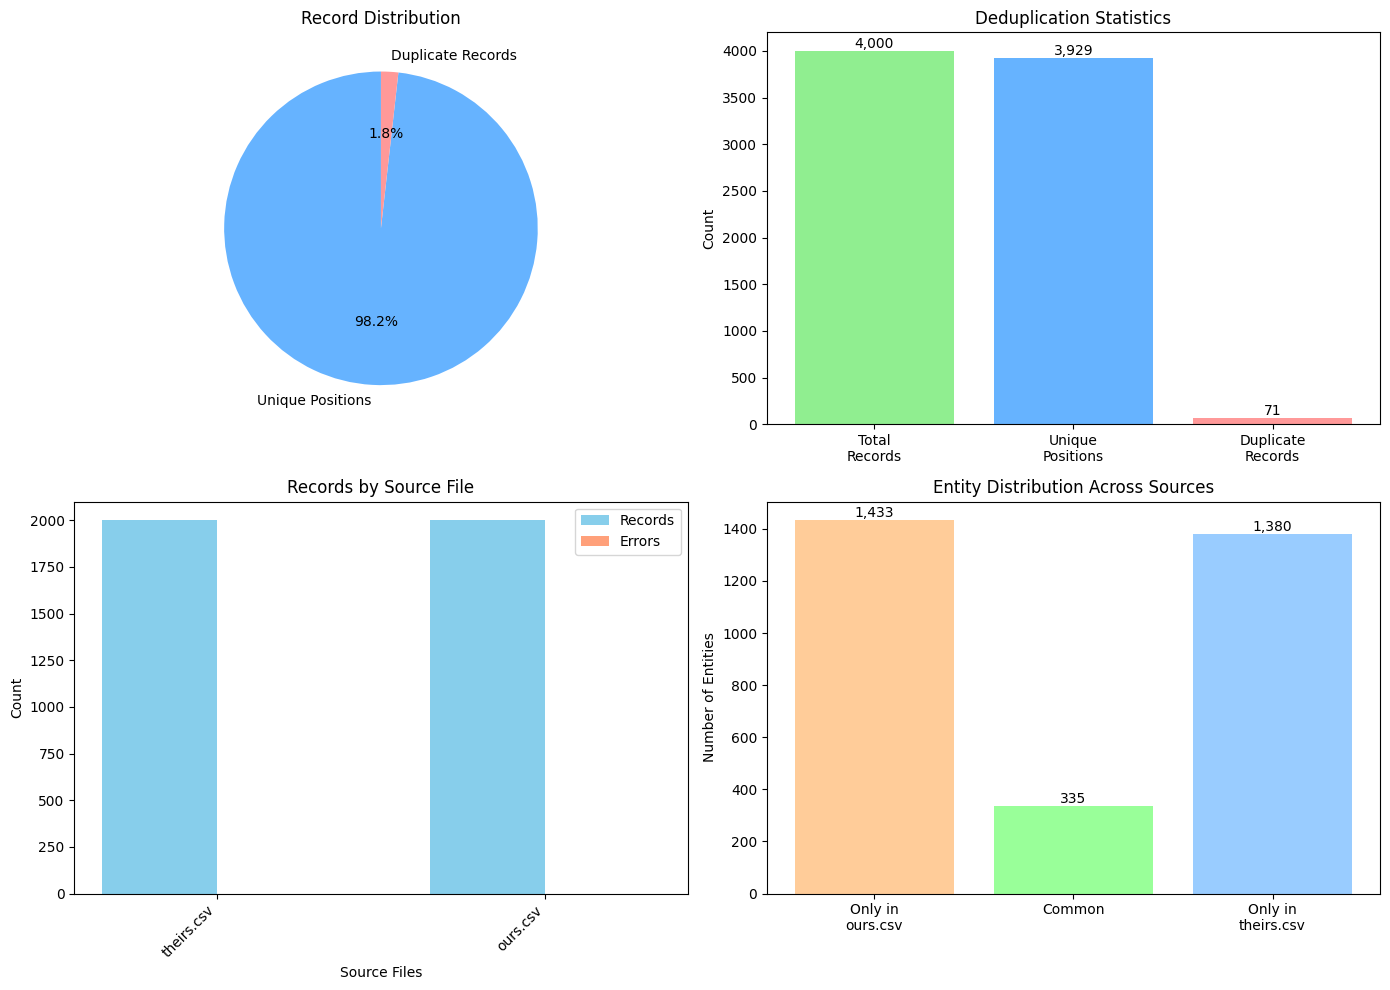


Overall Deduplication Rate: 1.8%


In [42]:
import matplotlib.pyplot as plt

# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# 1. Pie chart for record distribution
labels = ['Unique Positions', 'Duplicate Records']
sizes = [dedup_stats['unique_positions'], dedup_stats['duplicate_records']]
colors = ['#66b3ff', '#ff9999']

ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Record Distribution')

# 2. Bar chart for deduplication statistics
stats_labels = ['Total\nRecords', 'Unique\nPositions', 'Duplicate\nRecords']
stats_values = [
    dedup_stats['total_records'],
    dedup_stats['unique_positions'],
    dedup_stats['duplicate_records']
]

bars = ax2.bar(stats_labels, stats_values, color=['#90ee90', '#66b3ff', '#ff9999'])
ax2.set_title('Deduplication Statistics')
ax2.set_ylabel('Count')

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom')

# 3. Source file comparison
if sources:
    source_names = [s['source_file'] for s in sources[:5]]  # Show up to 5 sources
    source_records = [s['total_records'] for s in sources[:5]]
    source_errors = [s['total_errors'] or 0 for s in sources[:5]]
    
    x_pos = range(len(source_names))
    width = 0.35
    
    bars1 = ax3.bar([p - width/2 for p in x_pos], source_records, width, label='Records', color='#87ceeb')
    bars2 = ax3.bar([p + width/2 for p in x_pos], source_errors, width, label='Errors', color='#ffa07a')
    
    ax3.set_xlabel('Source Files')
    ax3.set_ylabel('Count')
    ax3.set_title('Records by Source File')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(source_names, rotation=45, ha='right')
    ax3.legend()

# 4. Entity overlap visualization (if both sources processed)
if 'common_entities' in locals():
    venn_data = [
        len(only_ours),
        len(common_entities),
        len(only_theirs)
    ]
    venn_labels = ['Only in\nours.csv', 'Common', 'Only in\ntheirs.csv']
    venn_colors = ['#ffcc99', '#99ff99', '#99ccff']
    
    bars = ax4.bar(venn_labels, venn_data, color=venn_colors)
    ax4.set_title('Entity Distribution Across Sources')
    ax4.set_ylabel('Number of Entities')
    
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}',
                 ha='center', va='bottom')
else:
    ax4.text(0.5, 0.5, 'Source comparison\nnot available', 
             ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Entity Distribution')

plt.tight_layout()
plt.show()

print(f"\nOverall Deduplication Rate: {dedup_stats['deduplication_rate']:.1%}")